## 2.1 理论计算题

1.向量点积a·b:
2×1+(-1)×4+3×(-2)=2-4-6=-8

2.矩阵乘法A×B:
A是2×3矩阵，B是3×2矩阵。结果矩阵形状为2×2。
C11=1(2)+0(0)+2(3)=8
C12=1(1)+0(-1)+2(2)=5
C21=-1(2)+3(0)+1(3)=1
C22=-1(1)+3(-1)+1(2)=-2
结果矩阵：
[8,5]
[1,-2]

3.向量 a 的 Frobenius 范数:
∥a∥F=√(2^2+（-1）^2+3^2)=√(8+1+9)=√(14)=3.74


In [1]:
import numpy as np

# 1. 创建 3x4 标准正态分布矩阵 X
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 创建 4x2 的全1矩阵 Y
Y = np.ones((4, 2))
print("\nY:\n", Y)

# 3. 计算 Z = X * Y
Z = X @ Y  # 或者使用 np.dot(X, Y)
print("\nZ:\n", Z)

# 4. 输出特定元素
print("\nZ的第一行第二列交叉处元素:", Z[0, 1])
print("Z的第2行所有元素:", Z[1, :]) # 注意Python索引从0开始，如果是"第2行"通常指索引1

# 5. 计算 Z 的 Frobenius 范数
f_norm = np.linalg.norm(Z, ord='fro')
print("\nZ的 Frobenius 范数:", f_norm)

X:
 [[-1.81775445 -0.38275928 -0.30009778  0.78613563]
 [-0.05101718 -0.34920196  0.30762743 -0.47305077]
 [ 0.2968783  -0.13045114 -1.65068432  0.34509223]]

Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z:
 [[-1.71447588 -1.71447588]
 [-0.56564248 -0.56564248]
 [-1.13916493 -1.13916493]]

Z的第一行第二列交叉处元素: -1.714475883634818
Z的第2行所有元素: [-0.56564248 -0.56564248]

Z的 Frobenius 范数: 3.018965288446974


## 3.1理论计算题

设患病为事件D,未患病为D。检测呈阳性为事件T。
已知：P(D)=0.001,P(D-)=0.999,P(T|D)=0.99,P(T|D-)=0.02
求：P(D|T)
根据贝叶斯公式：
P(D|P)=P(P|D)P(D)/P(T|D)P(D)+P(P|D-)P(D-)
=0.99*0.001/0.99*0.001+0.02*0.999≈0.00472

答：他真正患病的概率约为4.72%。

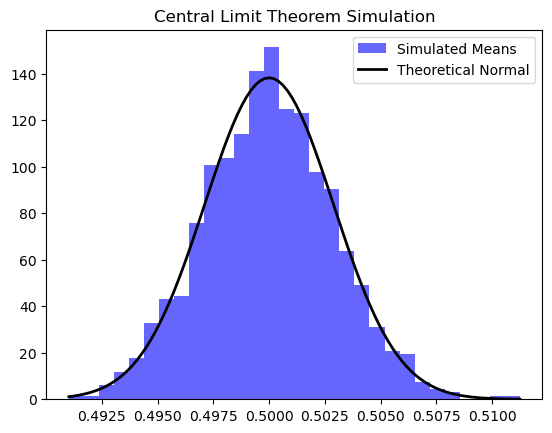

实际方差: 0.00000847
理论方差: 0.00000833


In [2]:
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000
m = 1000

# 1. 生成数据并计算均值
# U(0,1) 的期望是 0.5，方差是 1/12
samples = np.random.uniform(0, 1, size=(m, n))
means = np.mean(samples, axis=1)

# 2. 绘制直方图并叠加理论正态分布
plt.hist(means, bins=30, density=True, alpha=0.6, color='b', label='Simulated Means')

# 理论正态分布: mu = 0.5, sigma^2 = (1/12) / n
mu_theory = 0.5
std_theory = np.sqrt((1/12) / n)
x = np.linspace(min(means), max(means), 100)
p = norm.pdf(x, mu_theory, std_theory)
plt.plot(x, p, 'k', linewidth=2, label='Theoretical Normal')
plt.title('Central Limit Theorem Simulation')
plt.legend()
plt.show()

# 3. 计算实际方差
actual_variance = np.var(means)
print(f"实际方差: {actual_variance:.8f}")
print(f"理论方差: {(1/12)/n:.8f}")

## 4.1 理论计算题

### 4.1 理论计算题

函数： $z = (w_1x_1 + w_2x_2 - y)^2$

1. **偏导数表达式**（按链式法则）：
$$ \frac{\partial z}{\partial w_1} = 2(w_1x_1 + w_2x_2 - y) \cdot x_1 $$
$$ \frac{\partial z}{\partial w_2} = 2(w_1x_1 + w_2x_2 - y) \cdot x_2 $$

2. **代入计算**（$x_1=2, x_2=1, y=3, w_1=0.5, w_2=1$）：

括号内部 $= 0.5(2) + 1(1) - 3 = 1 + 1 - 3 = -1$

$$ \frac{\partial z}{\partial w_1} = 2(-1) \cdot 2 = -4 $$
$$ \frac{\partial z}{\partial w_2} = 2(-1) \cdot 1 = -2 $$

In [1]:
import torch

x, w1, w2 = 2.0, 1.5, 0.5

# 1 & 2. 手动前向计算
a = x * w1
b = a + w2
L = b**2
print(f"前向计算结果 L: {L}") # 预期: (2*1.5 + 0.5)^2 = 3.5^2 = 12.25

# 3. 手动计算梯度 (链式法则)
# dL/db = 2b = 2(3.5) = 7
# db/dw2 = 1 => dL/dw2 = 7 * 1 = 7
# db/da = 1, da/dw1 = x = 2 => dL/dw1 = dL/db * db/da * da/dw1 = 7 * 1 * 2 = 14
grad_w1_manual = 2 * (x * w1 + w2) * x
grad_w2_manual = 2 * (x * w1 + w2) * 1
print(f"手动计算梯度: dw1={grad_w1_manual}, dw2={grad_w2_manual}")

# 使用 torch.autograd 验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t**2

L_t.backward()
print(f"Autograd计算梯度: dw1={w1_t.grad.item()}, dw2={w2_t.grad.item()}")

前向计算结果 L: 12.25
手动计算梯度: dw1=14.0, dw2=7.0
Autograd计算梯度: dw1=14.0, dw2=7.0


## 5.1 理论计算题



损失函数： $L = \frac{1}{n} \sum_{i=1}^n (y_i - (wx_i + b))^2$

推导偏导数：

对 $w$ 求偏导：
$$ \frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^n 2(y_i - wx_i - b) \cdot (-x_i) = -\frac{2}{n} \sum_{i=1}^n x_i(y_i - (wx_i + b)) $$

对 $b$ 求偏导：
$$ \frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^n 2(y_i - wx_i - b) \cdot (-1) = -\frac{2}{n} \sum_{i=1}^n (y_i - (wx_i + b)) $$

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据
digits = load_digits()
X = digits.data  # 形状: (n_samples, 64)
y = digits.target

# 2. 划分数据集与 One-hot 编码
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

y_train_oh = one_hot(y_train, 10)
y_test_oh = one_hot(y_test, 10)

# 3. 定义 softmax 和 交叉熵损失
def softmax(z):
    # 减去最大值防止指数爆炸(数值稳定性)
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    # 加上微小值防止 log(0)
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

# 4. 初始化参数与小批量随机梯度下降
W = np.random.randn(64, 10) * 0.01
b = np.zeros(10)

batch_size = 32
lr = 0.1
epochs = 50
n_samples = X_train.shape[0]

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(n_samples)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train_oh[indices]
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = np.dot(X_batch, W) + b
        y_pred = softmax(logits)
        
        # 梯度计算
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / X_batch.shape[0]
        db = np.sum(dz, axis=0) / X_batch.shape[0]
        
        # 参数更新
        W -= lr * dW
        b -= lr * db

# 5. 测试集准确率
test_logits = np.dot(X_test, W) + b
test_preds = np.argmax(softmax(test_logits), axis=1)
accuracy = np.mean(test_preds == y_test)
print(f"测试集准确率: {accuracy * 100:.2f}%")

测试集准确率: 96.67%


## 6.1 理论计算题



已知样本 $x_i \sim \mathcal{N}(\mu, \sigma^2)$。

1. **似然函数 $L(\mu, \sigma^2)$**:
$$ L(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right) $$

2. **证明 $\hat{\mu} = \frac{1}{n}\sum x_i$**:

   取对数似然 $\ln L = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2$
   
   对 $\mu$ 求导并令其为 0：
$$ \frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0 $$
$$ \implies \sum_{i=1}^n x_i - n\mu = 0 \implies \hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i \text{ (得证)} $$

3. **证明 $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i - \hat{\mu})^2$**:

   对 $\sigma^2$ 求导并令其为 0：
$$ \frac{\partial \ln L}{\partial (\sigma^2)} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^n (x_i - \mu)^2 = 0 $$
   
   两边同乘 $2(\sigma^2)^2$：
$$ -n\sigma^2 + \sum_{i=1}^n (x_i - \mu)^2 = 0 \implies \hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2 \text{ (得证)} $$

逻辑回归测试集准确率: 52.00%


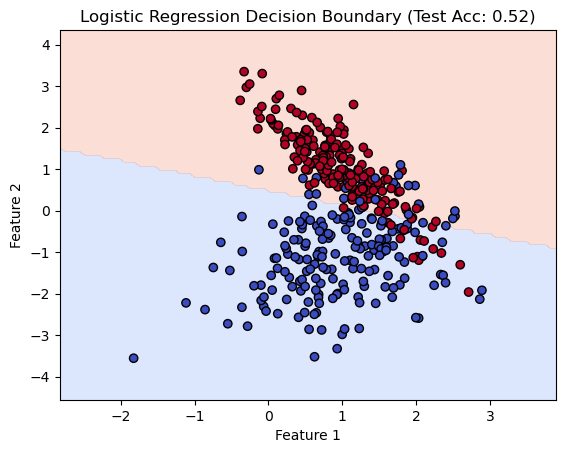

In [9]:
from sklearn.datasets import make_classification

# 1. 生成数据 (400个样本，训练用)
X_bin, y_bin = make_classification(n_samples=400, n_features=2, n_redundant=0, 
                                   n_clusters_per_class=1, random_state=42)

# 2. 定义 sigmoid 和 二元交叉熵
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15) # 防止 log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# 3. 梯度下降学习参数
w = np.zeros(2)
b_val = 0.0
lr = 0.1
iterations = 1000
n_s = X_bin.shape[0]

for i in range(iterations):
    z = np.dot(X_bin, w) + b_val
    p = sigmoid(z)
    
    # 梯度
    dw = np.dot(X_bin.T, (p - y_bin)) / n_s
    db = np.mean(p - y_bin)
    
    # 更新
    w -= lr * dw
    b_val -= lr * db

# 4. 测试集评估与绘制决策边界
# 生成新测试集 (100个)
X_test_bin, y_test_bin = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                                             n_clusters_per_class=1, random_state=99)
p_test = sigmoid(np.dot(X_test_bin, w) + b_val)
y_pred_bin = (p_test >= 0.5).astype(int)
acc_bin = np.mean(y_pred_bin == y_test_bin)
print(f"逻辑回归测试集准确率: {acc_bin * 100:.2f}%")

# 绘制边界
x1_min, x1_max = X_bin[:, 0].min() - 1, X_bin[:, 0].max() + 1
x2_min, x2_max = X_bin[:, 1].min() - 1, X_bin[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
Z_grid = sigmoid(np.dot(np.c_[xx1.ravel(), xx2.ravel()], w) + b_val)
Z_grid = (Z_grid >= 0.5).reshape(xx1.shape)

plt.contourf(xx1, xx2, Z_grid, alpha=0.3, cmap='coolwarm')
plt.scatter(X_bin[:, 0], X_bin[:, 1], c=y_bin, cmap='coolwarm', edgecolors='k')
plt.title(f"Logistic Regression Decision Boundary (Test Acc: {acc_bin:.2f})")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()